# Correct Misannotation of MgkPro as HSCs.

## Prepare Notebook.

### Import Libraries.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
from scipy.stats import gaussian_kde
import seaborn as sns


### Load Data.

In [2]:
adata_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/loop2/BloodPlus_Loop2_logicle_500k_combined.h5ad"
adata = sc.read_h5ad(adata_path)
adata

/lustre/groups/ml01/workspace/lorenzo.consoli/micromamba/envs/sc_exp_design/lib/python3.12/site-packages/anndata/_core/anndata.py:1878: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 971828 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type'
    obsm: 'X_umap'
    layers: 'positives', 'raw'

### Split between new and old.

In [3]:
adata_new = adata[-499992:]
adata_old = adata[:-499992]
print(adata_new)
print(adata_old)

View of AnnData object with n_obs × n_vars = 499992 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type'
    obsm: 'X_umap'
    layers: 'positives', 'raw'
View of AnnData object with n_obs × n_vars = 471836 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', '

### Get all the MgkPro cells in a separate anndata.

In [4]:
# full data
MgkPro_mask = adata.obs.cell_type == "late_MgkPro"
adata_MgkPro = adata[MgkPro_mask]
print("Concat: ", adata_MgkPro)

# new data
MgkPro_mask_new = adata_new.obs.cell_type == "late_MgkPro"
adata_new_MgkPro = adata_new[MgkPro_mask_new]
print("New: ", adata_new_MgkPro)

# old data
MgkPro_mask_old = adata_old.obs.cell_type == "late_MgkPro"
adata_old_MgkPro = adata_old[MgkPro_mask_old]
print("Old: ", adata_old_MgkPro)

Concat:  View of AnnData object with n_obs × n_vars = 58014 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type'
    obsm: 'X_umap'
    layers: 'positives', 'raw'
New:  View of AnnData object with n_obs × n_vars = 53544 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_

### Get all the HSCs cells in a separate anndata.

In [5]:
# full data
HSCs_mask = adata.obs.cell_type == "HSCs"
adata_HSCs = adata[HSCs_mask]
print("Concat: ", adata_HSCs)

# old data
HSCs_mask_new = adata_new.obs.cell_type == "HSCs"
adata_new_HSCs = adata_new[HSCs_mask_new]
print("New: ", adata_new_HSCs)

# new data
HSCs_mask_old = adata_old.obs.cell_type == "HSCs"
adata_old_HSCs = adata_old[HSCs_mask_old]
print("Old: ", adata_old_HSCs)

Concat:  View of AnnData object with n_obs × n_vars = 9518 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type'
    obsm: 'X_umap'
    layers: 'positives', 'raw'
New:  View of AnnData object with n_obs × n_vars = 6850 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_se

### Plot new adata by cell type.

/lustre/groups/ml01/workspace/lorenzo.consoli/micromamba/envs/sc_exp_design/lib/python3.12/site-packages/scanpy/plotting/_utils.py:509: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


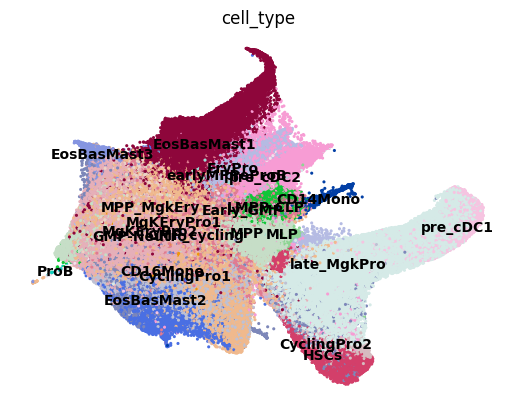

In [6]:
sc.pl.embedding(adata_new, "umap", color="cell_type", frameon=False, legend_loc="on data", s=20)

## Visualize Markers of the HSC Populations.

### Utility Function for Plotting.

In [7]:
def make_scatter_plot(
    input_adata,
    target_markers=["CD41a"],
    ref_markers=["CD34", "CD90", "EPCR"],
    base_size=4,
    offset_ratio=0.5,
    dpi=100,
    cmap='viridis',
    s=5,
    alpha=0.6,
    title=""
):
    # Helper function to add density-colored scatter points
    def _add_density_scatter(ax, x, y, cmap='viridis', s=5, alpha=0.6):
        """Compute 2D KDE and scatter points colored by density."""
        # Remove NaNs
        mask = ~(np.isnan(x) | np.isnan(y))
        x_clean = x[mask]
        y_clean = y[mask]
        if len(x_clean) == 0:
            return
        # Compute density estimate
        xy = np.vstack([x_clean, y_clean])
        kde = gaussian_kde(xy, bw_method='scott')
        density = kde(xy)
        # Plot with density color
        sc = ax.scatter(x_clean, y_clean, c=density, cmap=cmap, s=s, alpha=alpha, edgecolor='none')
        return sc

    def _get_marker_values(
        marker,
    ):
        if marker in input_adata.var_names:
            return input_adata[:, marker].X[:, 0]
        elif marker in input_adata.obs.columns:
            return input_adata.obs[marker].astype(float).values
        else:
            raise KeyError(f"{marker} not found.")

    # get values for marker
    tgt_marker_values_dict = {
       marker: _get_marker_values(marker)
        for marker in target_markers
    }
    ref_marker_values_dict = {
        marker: _get_marker_values(marker)
        for marker in ref_markers
    }

    # create figure
    n_tgt_markers = len(target_markers)
    n_ref_markers = len(ref_markers)
    fig_width = (n_ref_markers + offset_ratio)*base_size
    fig_height = (n_tgt_markers + offset_ratio)*base_size
    fig, all_ax = plt.subplots(n_tgt_markers, n_ref_markers, figsize=(fig_width, fig_height), dpi=dpi)
    fig.suptitle(title)

    # plot markers
    for tgt_idx, (tgt_marker_name, tgt_marker_values) in enumerate(tgt_marker_values_dict.items()):
        # get axes
        if n_tgt_markers > 1:
            tgt_ax = all_ax[tgt_idx]
        else:
            tgt_ax = all_ax
        for ref_idx, (ref_marker_name, ref_marker_values) in enumerate(ref_marker_values_dict.items()):
            # get axes
            if n_ref_markers > 1:
                cur_ax = tgt_ax[ref_idx]
            else:
                cur_ax = tgt_ax

            # define axes to plot
            y = tgt_marker_values
            x = ref_marker_values

            # plot density scatter
            _add_density_scatter(cur_ax, x, y, s=s, alpha=alpha)

            # set axes labels
            cur_ax.set_xlabel(ref_marker_name)
            cur_ax.set_ylabel(tgt_marker_name)

            # set title
            cur_ax.set_title(f"{ref_marker_name} vs {tgt_marker_name}")
    return fig, all_ax


### Plot Markers HSCs against others.

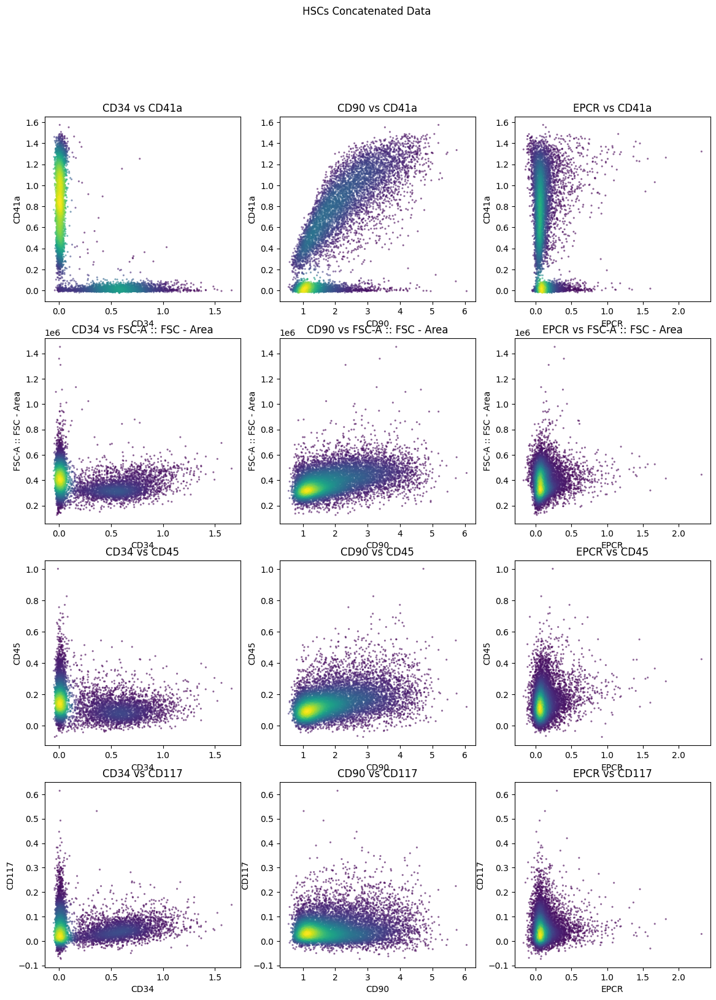

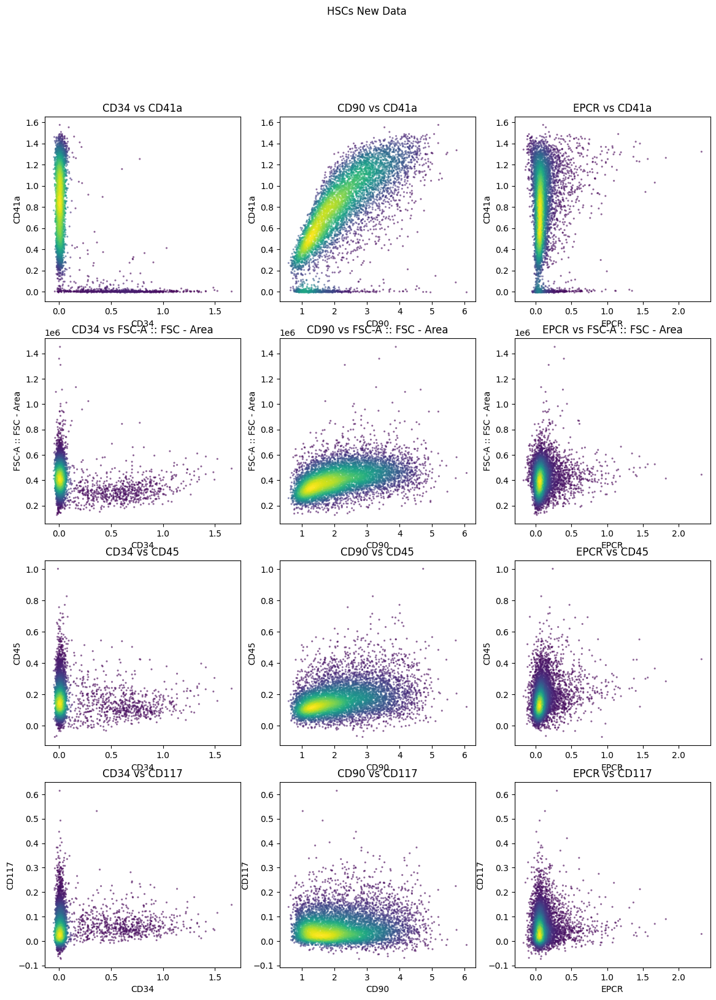

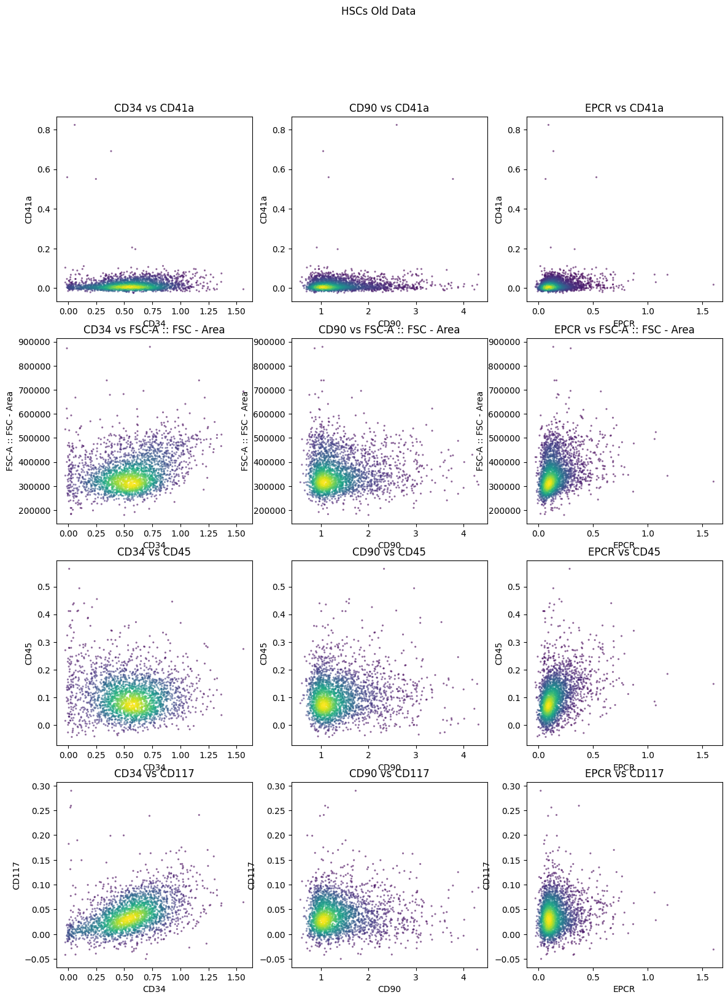

In [ ]:
# define markers
target_markers = ["CD41a", "FSC-A :: FSC - Area", "CD45", "CD117"]
ref_markers = ["CD34", "CD90", "EPCR", ""]

# plot concatenated data
_ = make_scatter_plot(
    adata_HSCs,
    target_markers=target_markers,
    ref_markers=ref_markers,
    title="HSCs Concatenated Data"
)

# plot new data
_ = make_scatter_plot(
    adata_new_HSCs,
    target_markers=target_markers,
    ref_markers=ref_markers,
    title="HSCs New Data"
)

# plot old data
_ = make_scatter_plot(
    adata_old_HSCs,
    target_markers=target_markers,
    ref_markers=ref_markers,
    title="HSCs Old Data"
)

### Plot markers MgkPro against others.

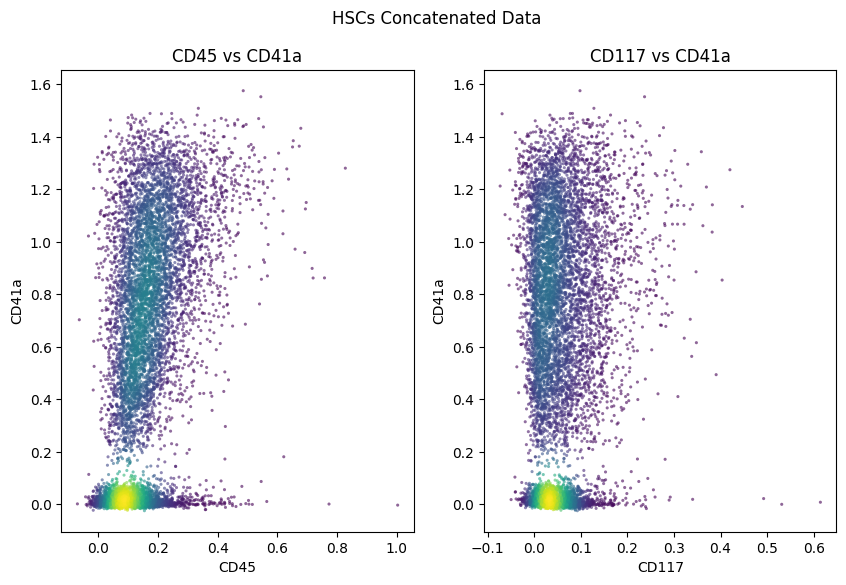

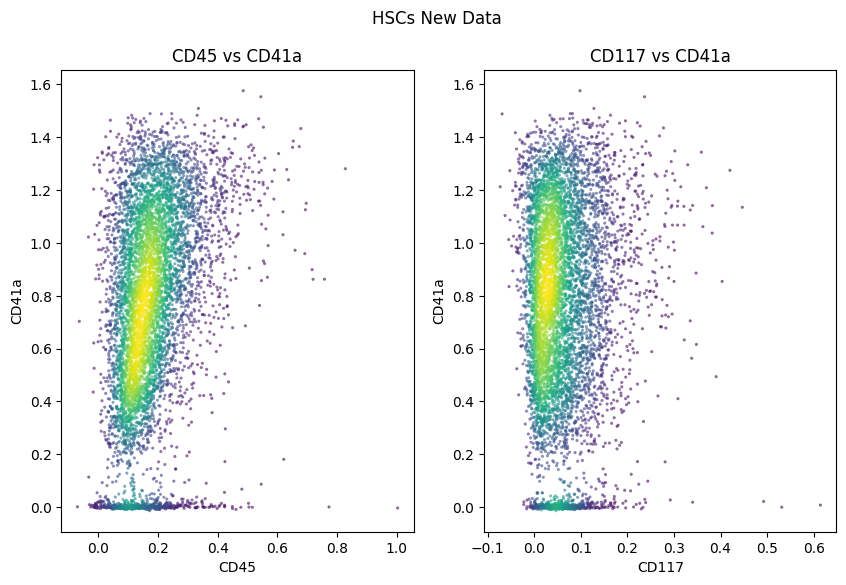

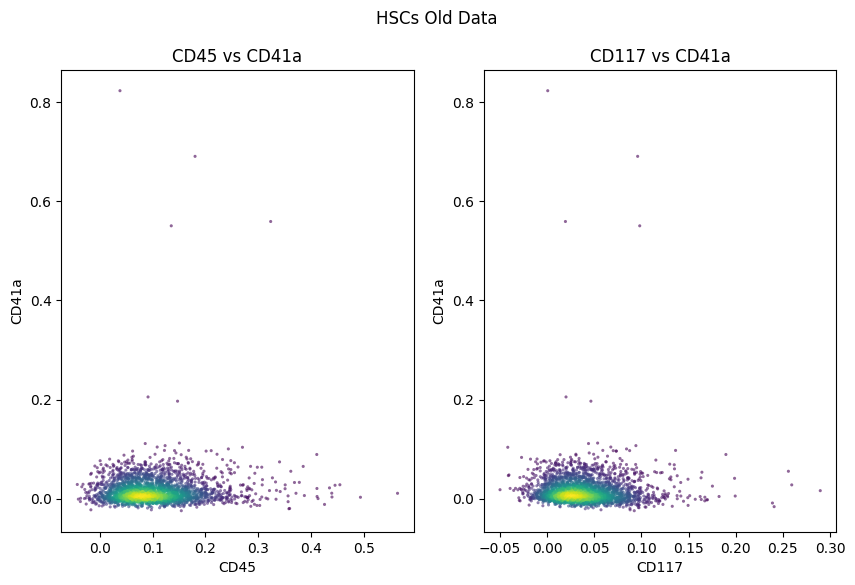

In [9]:
# define markers
target_markers = ["CD41a"]
ref_markers = ["CD45", "CD117"]

# plot concatenated data
_ = make_scatter_plot(
    adata_HSCs,
    target_markers=target_markers,
    ref_markers=ref_markers,
    title="HSCs Concatenated Data"
)

# plot new data
_ = make_scatter_plot(
    adata_new_HSCs,
    target_markers=target_markers,
    ref_markers=ref_markers,
    title="HSCs New Data"
)

# plot old data
_ = make_scatter_plot(
    adata_old_HSCs,
    target_markers=target_markers,
    ref_markers=ref_markers,
    title="HSCs Old Data"
)


### Dotplots HSCs annotated cells.

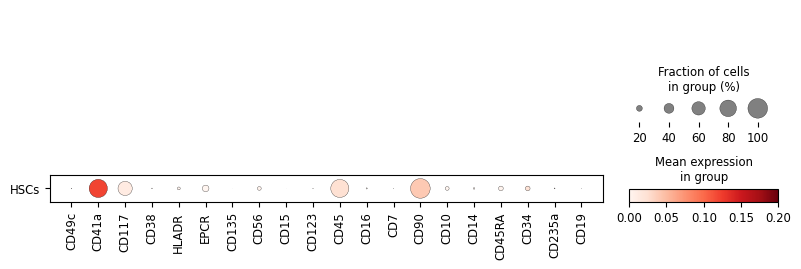

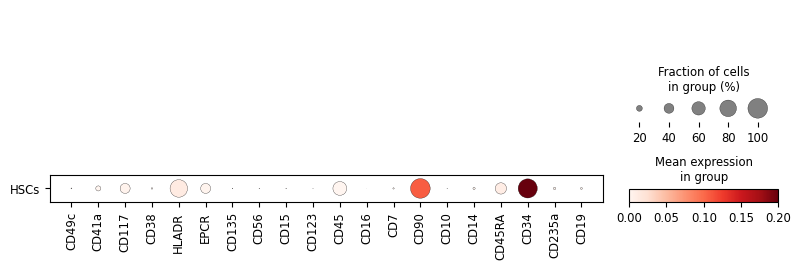

In [29]:
# var_names = ["CD34", "CD90", "EPCR", "CD45", "CD117", "CD41a"]
var_names = adata_new_HSCs.var_names
sc.pl.dotplot(
    adata_new_HSCs,
    var_names,
    "cell_type",
    vmin=0.0,
    vmax=0.2
)
sc.pl.dotplot(
    adata_old_HSCs,
    var_names,
    "cell_type",
    vmin=0.0,
    vmax=0.2
)

### Dotplots MgkPro annotated cells.

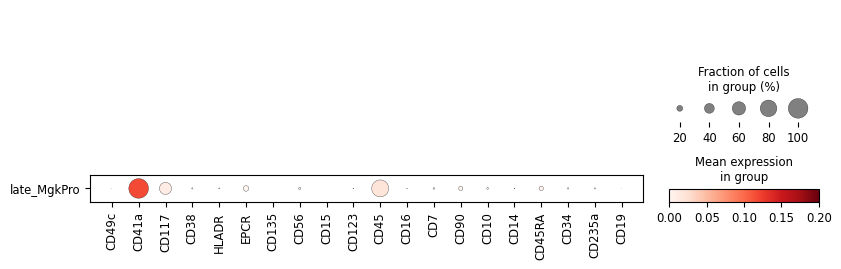

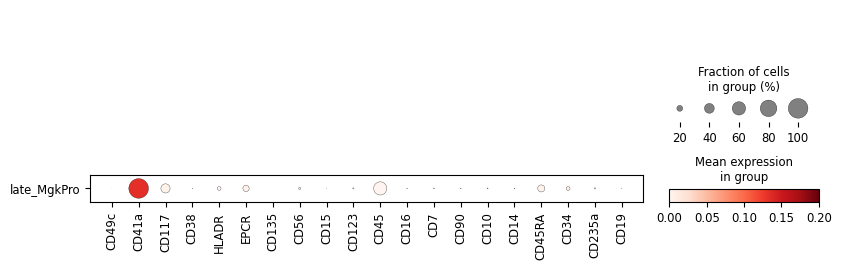

In [34]:
sc.pl.dotplot(
    adata_new_MgkPro,
    var_names,
    "cell_type",
    vmin=0.0,
    vmax=0.2,
)
sc.pl.dotpleot(
    adata_old_MgkPro,
    var_names,
    "cell_type",
    vmin=0.0,
    vmax=0.2,
)

## Visualize Markers and Cell Types in UMAP Space.

### Plot.

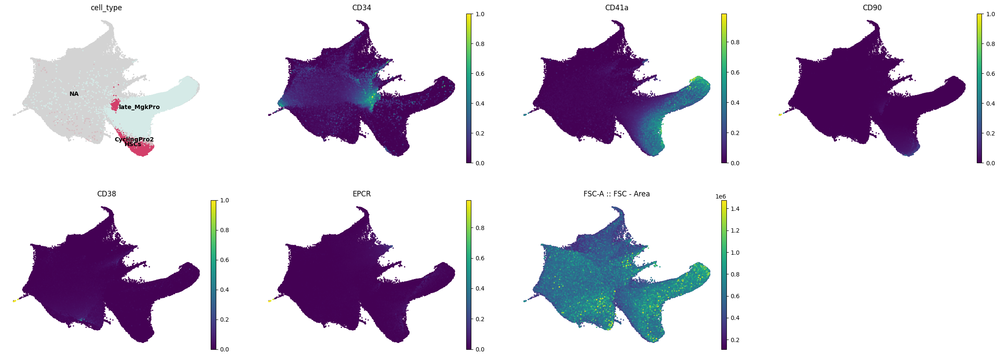

/lustre/groups/ml01/workspace/lorenzo.consoli/micromamba/envs/sc_exp_design/lib/python3.12/site-packages/scanpy/plotting/_utils.py:509: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


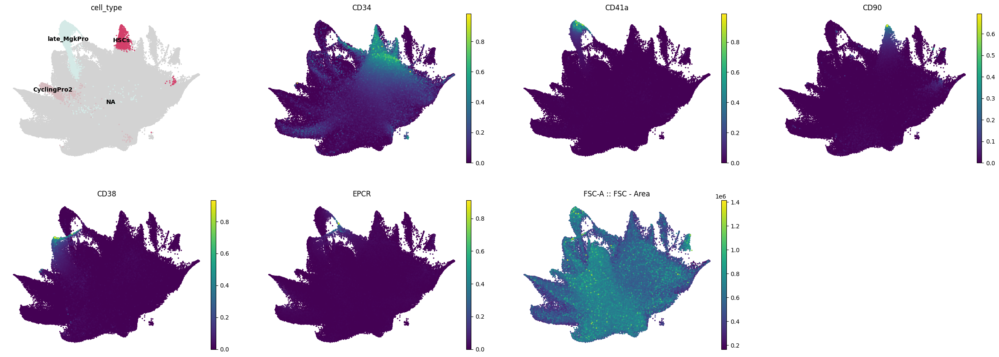

In [10]:
color = ["cell_type", "CD34", "CD41a", "CD90", 'CD38', "EPCR", "FSC-A :: FSC - Area"]
groups = ["HSCs", "late_MgkPro", "CyclingPro2"]
frameon=False
legend_loc="on data"
s=20

sc.pl.embedding(adata_new, "umap", color=color, groups=groups, frameon=frameon, legend_loc=legend_loc, s=s)
sc.pl.embedding(adata_old, "umap", color=color, groups=groups, frameon=frameon, legend_loc=legend_loc, s=s)


# Stragegy A: Annotate HSCs cells expressing CD41a above a certain threshold as MgkPro.

## Get threshold from original data (Max CD41a expression over HSCs cells).


### Utility Function for Updating Annotation.

In [11]:
def reannotate_cell_types_with_threshold_on_marker_gene(
    input_adata,
    threshold,
    current_ct="HSCs",
    target_ct="late_MgkPro",
    marker="CD41a",
    margin=0.0,
    key_to_add=None,
    is_reannot_key=None,
):
    def _get_marker_values(
        marker,
    ):
        if marker in input_adata.var_names:
            return input_adata[:, marker].X[:, 0]
        elif marker in input_adata.obs.columns:
            return input_adata.obs[marker].astype(float).values
        else:
            raise KeyError(f"{marker} not found.")

    # log message
    print(f"---- Reannotating Input Anndata ---")
    n_cells = input_adata.shape[0]
    print(f"Input Anndata contains {n_cells}")

    # Ensure target category exists
    if target_ct not in input_adata.obs["cell_type"].cat.categories:
        input_adata.obs["cell_type"] = input_adata.obs["cell_type"].cat.add_categories([target_ct])

    # get marker values
    marker_values = _get_marker_values(marker)

    # compute effective threshold
    eff_threshold = threshold*(1 + margin)
    print(
        f"Reannotating cells from {current_ct} to {target_ct} based "
        f"on marker {marker} with threshold of {threshold:3f} and margin {margin:3f} (Effective {eff_threshold:3f})."
    )

    # get masks for cell type
    current_ct_mask = input_adata.obs["cell_type"].values == current_ct
    n_cell_ct = current_ct_mask.sum()
    print(f"Found {n_cell_ct} for cell type {current_ct}")

    # get mask for threshold
    marker_mask = marker_values > eff_threshold
    n_marker_thresh = marker_mask.sum() 
    print(f"Found {n_marker_thresh} cells exceeding threshold for marker {marker}.")

    # get combined mask
    reannot_mask = current_ct_mask & marker_mask
    n_cells_to_reannot = reannot_mask.sum()
    print(
        f"Found {n_cells_to_reannot} to reannotate."
    )

    # log message and early exit
    if n_cells_to_reannot == 0:
        print("No cells to reannotate, exiting!")
        return input_adata

    # create updated annotation values
    updated_annot = input_adata.obs["cell_type"].values.copy()
    updated_annot[reannot_mask] = target_ct

    # write reannotated column on obs
    if is_reannot_key is None:
        is_reannot_key = f"reannot_m:{marker}_t:{threshold:2f}+{margin:2f}"
    input_adata.obs[is_reannot_key] = reannot_mask
    print(f"Reannotation Flag written to .obs at key {is_reannot_key}")

    # write to adata
    if key_to_add is None:
        key_to_add = f"cell_type_m:{marker}_t:{threshold:2f}+{margin:2f}"
    input_adata.obs[key_to_add] = updated_annot
    print(f"Updated annotations written to .obs at key {key_to_add}")
    print(f"---- Reannotation Done! ---")
    return input_adata


### Update annotation.

In [12]:
# ---- Get threshold expression values of CD41a from HSCs ----
# Get arrays of CD41a expression
X_CD41a_old_HSCs = adata_old_HSCs[:, "CD41a"].X[:, 0]
X_CD41a_new_HSCs = adata_new_HSCs[:, "CD41a"].X[:, 0]

# Get maximum value of CD41a expression from original HSCs
max_threshold = X_CD41a_old_HSCs.max()
print(f"Threshold from old data -> {max_threshold}")

# ---- Reannotate adatas ----
key_to_add = "cell_type_max_threshold"
is_reannot_key = "is_reannot_max_threshold"
adata_new = reannotate_cell_types_with_threshold_on_marker_gene(
    adata_new,
    max_threshold,
    key_to_add=key_to_add,
    is_reannot_key=is_reannot_key
)


Threshold from old data -> 0.8229807615280151
---- Reannotating Input Anndata ---
Input Anndata contains 499992
Reannotating cells from HSCs to late_MgkPro based on marker CD41a with threshold of 0.822981 and margin 0.000000 (Effective 0.822981).
Found 6850 for cell type HSCs
Found 29130 cells exceeding threshold for marker CD41a.
Found 3192 to reannotate.
Reannotation Flag written to .obs at key is_reannot_max_threshold
Updated annotations written to .obs at key cell_type_max_threshold
---- Reannotation Done! ---


### Plot Cells after with updated annotations.

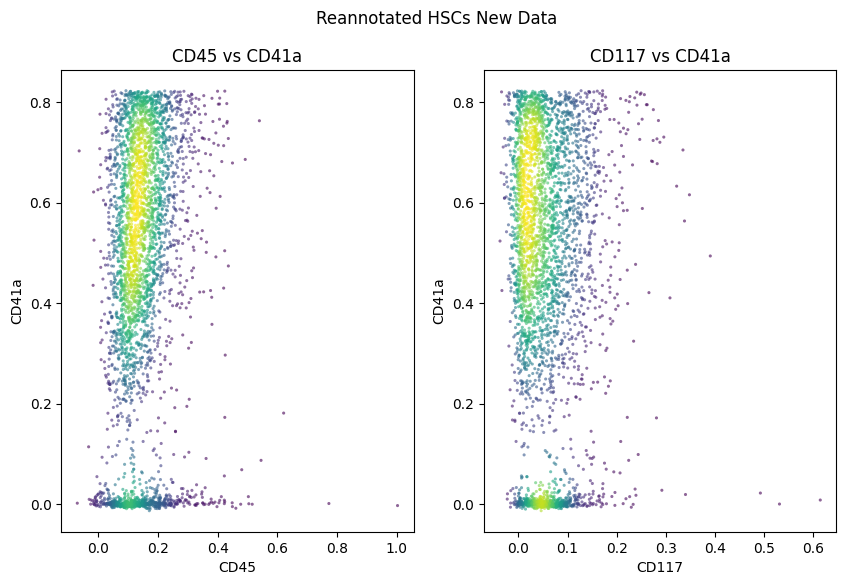

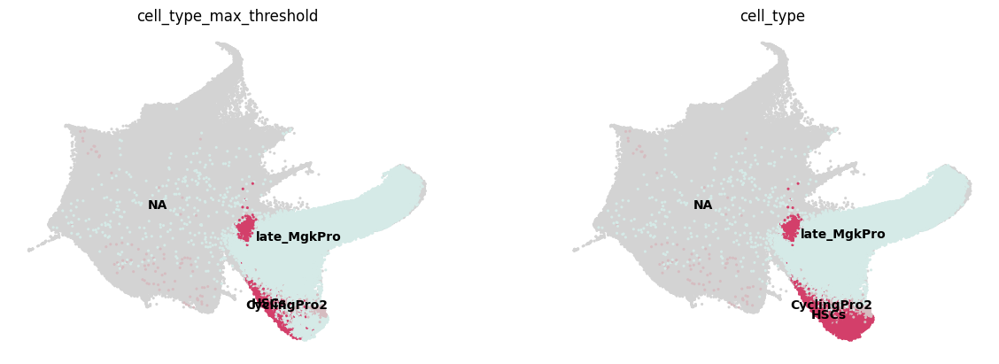

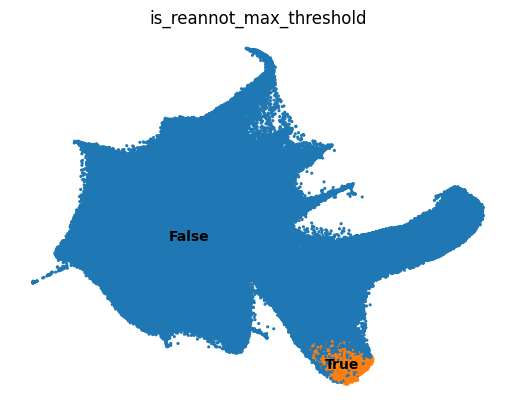

In [13]:
# slice anndatas again
adata_new_HSCs_max_thresh = adata_new[adata_new.obs[key_to_add] == "HSCs"]

# plot new data
_ = make_scatter_plot(
    adata_new_HSCs_max_thresh,
    target_markers=target_markers,
    ref_markers=ref_markers,
    title="Reannotated HSCs New Data"
)
sc.pl.embedding(adata_new, "umap", color=[key_to_add, "cell_type"], groups=groups, frameon=frameon, legend_loc=legend_loc, s=s)
sc.pl.embedding(adata_new, "umap", color=[is_reannot_key], frameon=frameon, legend_loc=legend_loc, s=s)


## Get Threshold from percentile.

### Update annotation.

In [14]:
# ---- Get threshold expression values of CD41a from HSCs ----
# Get arrays of CD41a expression
X_CD41a_old_HSCs = adata_old_HSCs[:, "CD41a"].X[:, 0]
X_CD41a_new_HSCs = adata_new_HSCs[:, "CD41a"].X[:, 0]

# Get maximum value of CD41a expression from original HSCs
percentile = 75
third_quartile_threshold = np.percentile(X_CD41a_old_HSCs, percentile).item()
print(f"Threshold from old data -> {third_quartile_threshold}")

# ---- Reannotate adatas ----
key_to_add = "cell_type_third_quartile_threshold"
is_reannot_key = "is_reannot_third_quartile_threshold"
adata_new = reannotate_cell_types_with_threshold_on_marker_gene(
    adata_new,
    third_quartile_threshold,
    key_to_add=key_to_add,
    is_reannot_key=is_reannot_key
)


Threshold from old data -> 0.02594512514770031
---- Reannotating Input Anndata ---
Input Anndata contains 499992
Reannotating cells from HSCs to late_MgkPro based on marker CD41a with threshold of 0.025945 and margin 0.000000 (Effective 0.025945).
Found 6850 for cell type HSCs
Found 91719 cells exceeding threshold for marker CD41a.
Found 6164 to reannotate.
Reannotation Flag written to .obs at key is_reannot_third_quartile_threshold
Updated annotations written to .obs at key cell_type_third_quartile_threshold
---- Reannotation Done! ---


### Plot.

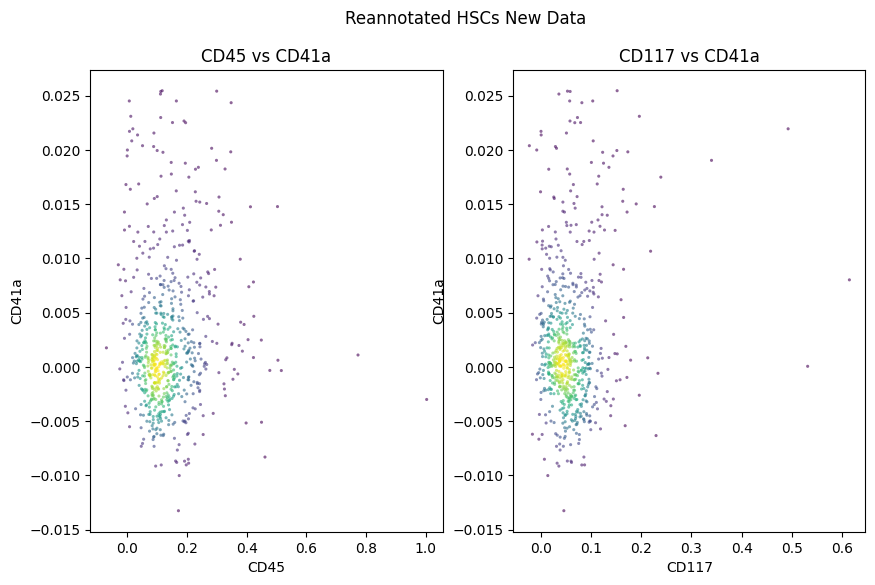

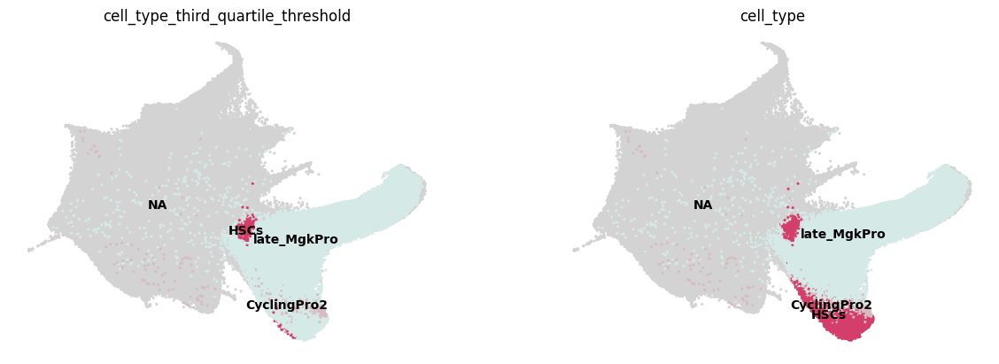

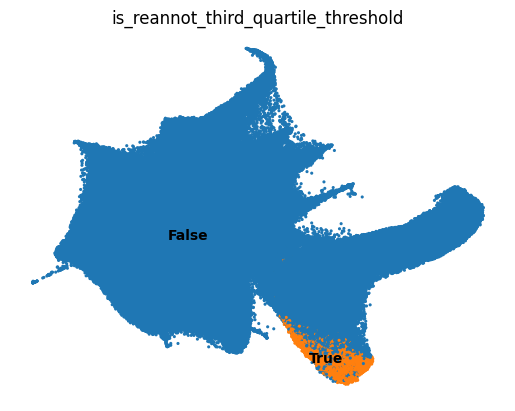

In [15]:
# slice anndatas again
adata_new_HSCs_third_quartile_thresh = adata_new[adata_new.obs[key_to_add] == "HSCs"]

# plot new data
_ = make_scatter_plot(
    adata_new_HSCs_third_quartile_thresh,
    target_markers=target_markers,
    ref_markers=ref_markers,
    title="Reannotated HSCs New Data"
)
sc.pl.embedding(adata_new, "umap", color=[key_to_add, "cell_type"], groups=groups, frameon=frameon, legend_loc=legend_loc, s=s)
sc.pl.embedding(adata_new, "umap", color=[is_reannot_key], frameon=frameon, legend_loc=legend_loc, s=s)


# Strategy B: Subcluster HSCs Annotated Cells.

### Run Leiden clustering on new anndata HSCs cells.

/tmp/ipykernel_671982/2398730757.py:9: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_new_HSCs)
/tmp/ipykernel_671982/2398730757.py:11: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_new_HSCs, resolution=0.075, key_added="leiden_0.75")
/tmp/i

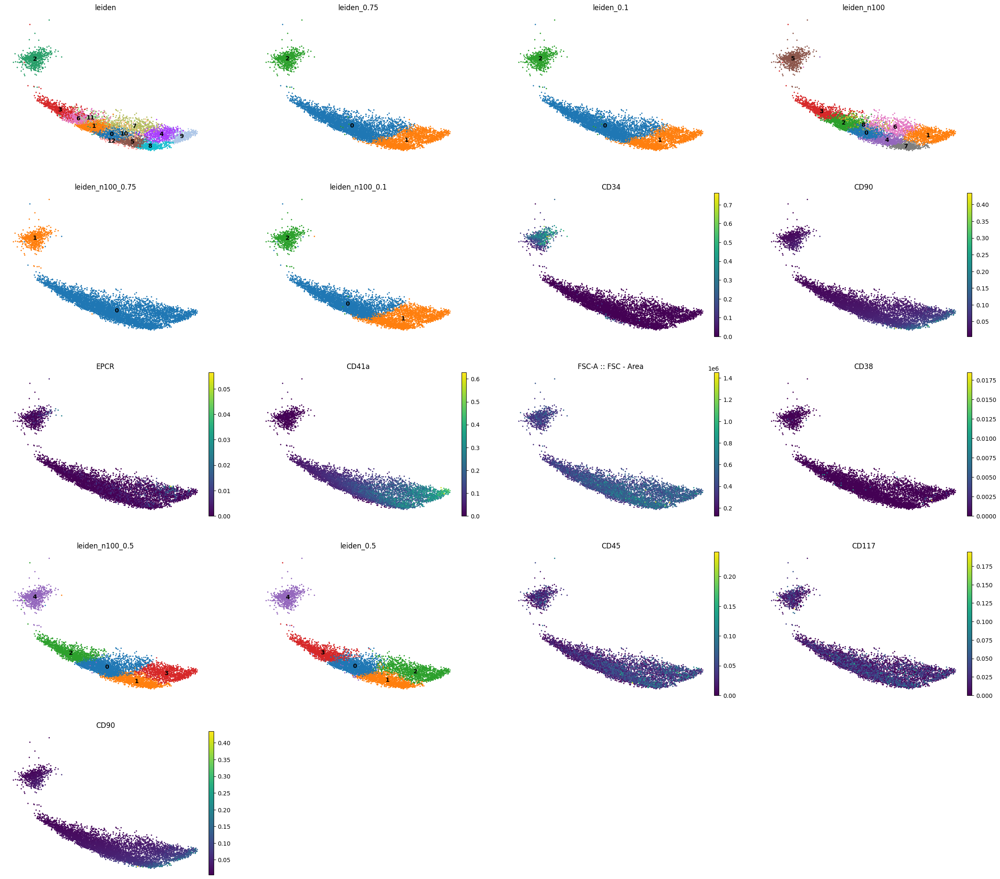

AnnData object with n_obs × n_vars = 6850 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type', 'leiden', 'leiden_0.75', 'leiden_0.5', 'leiden_0.1', 'leiden_n100', 'leiden_n100_0.75', 'leiden_n100_0.5', 'leiden_n100_0.1'
    uns: 'neighbors', 'neighbors_100', 'leiden', 'leiden_0.75', 'leiden_0.5', '

In [16]:
# neighbors
if "neighbors" not in adata_new_HSCs.uns.keys():
    sc.pp.neighbors(adata_new_HSCs)
if "neighbors_100" not in adata_new_HSCs.uns.keys():
    sc.pp.neighbors(adata_new_HSCs, n_neighbors=100, key_added="neighbors_100")

# leiden with default neighbors
if "leiden" not in adata_new_HSCs.obs.columns:
    sc.tl.leiden(adata_new_HSCs)
if "leiden_0.75" not in adata_new_HSCs.obs.columns:
    sc.tl.leiden(adata_new_HSCs, resolution=0.075, key_added="leiden_0.75")
if "leiden_0.5" not in adata_new_HSCs.obs.columns:
    sc.tl.leiden(adata_new_HSCs, resolution=0.5, key_added="leiden_0.5")
if "leiden_0.1" not in adata_new_HSCs.obs.columns:
    sc.tl.leiden(adata_new_HSCs, resolution=0.1, key_added="leiden_0.1")


# leiden with 100 neighbors
if "leiden_n100" not in adata_new_HSCs.obs.columns:
    sc.tl.leiden(adata_new_HSCs, key_added="leiden_n100", neighbors_key="neighbors_100")
if "leiden_n100_0.75" not in adata_new_HSCs.obs.columns:
    sc.tl.leiden(adata_new_HSCs, resolution=0.075, key_added="leiden_n100_0.75", neighbors_key="neighbors_100")
if "leiden_n100_0.5" not in adata_new_HSCs.obs.columns:
    sc.tl.leiden(adata_new_HSCs, resolution=0.5, key_added="leiden_n100_0.5", neighbors_key="neighbors_100")
if "leiden_n100_0.1" not in adata_new_HSCs.obs.columns:
    sc.tl.leiden(adata_new_HSCs, resolution=0.1, key_added="leiden_n100_0.1", neighbors_key="neighbors_100")

# plot
color = [
    "leiden", "leiden_0.75", "leiden_0.1", "leiden_n100", "leiden_n100_0.75",
    "leiden_n100_0.1", "CD34", "CD90", "EPCR", "CD41a", "FSC-A :: FSC - Area", "CD38",
    "leiden_n100_0.5", "leiden_0.5",  "CD45", "CD117", "CD90"
]
sc.pl.embedding(adata_new_HSCs, "umap", color=color, frameon=frameon, legend_loc=legend_loc, s=s)
adata_new_HSCs

### Plot HSCs by all var names.

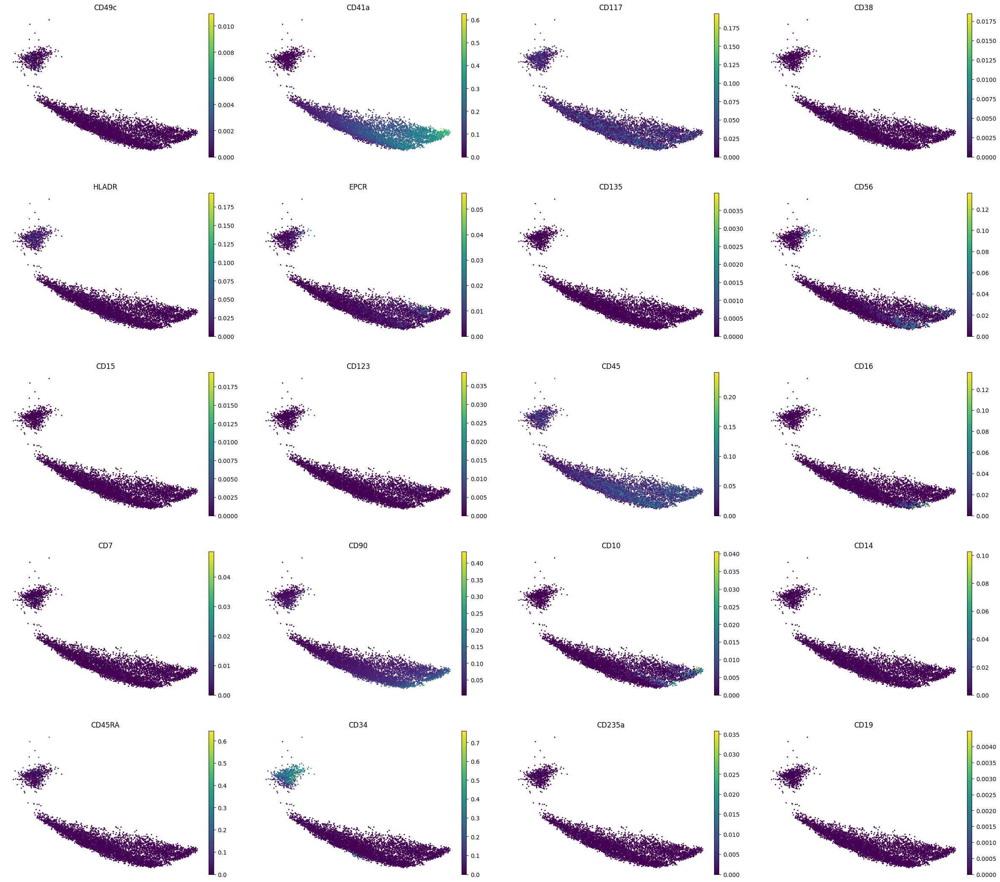

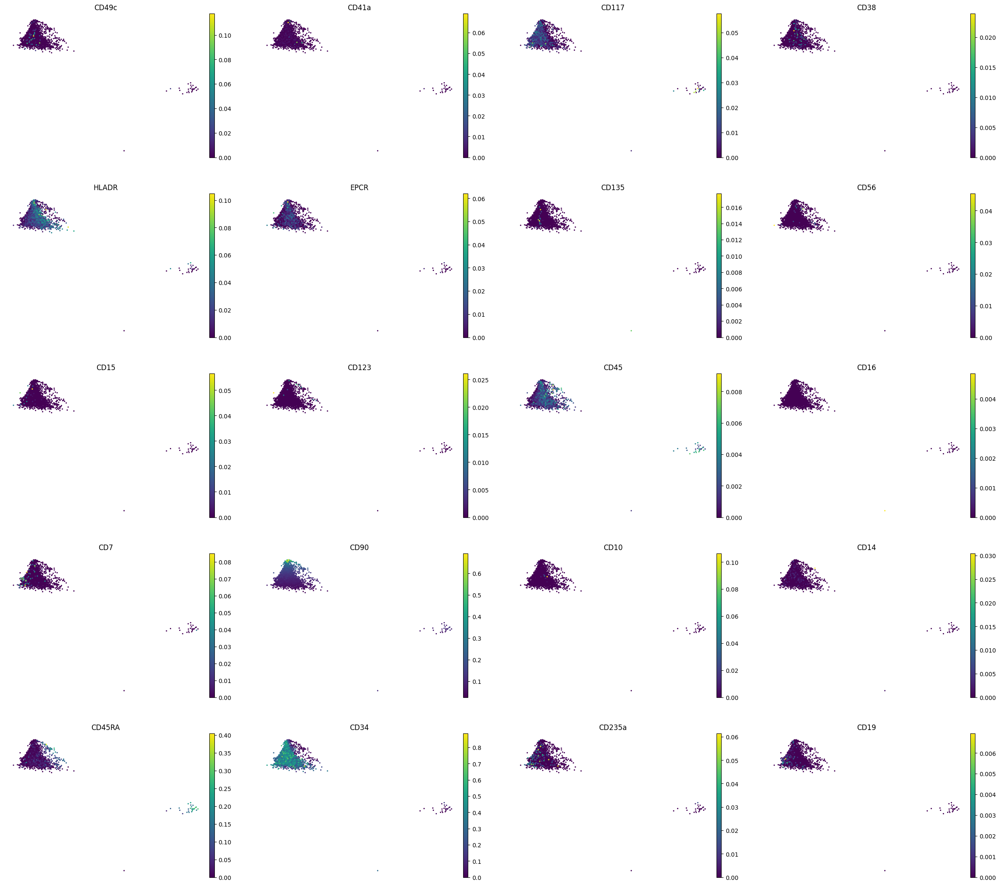

In [30]:
sc.pl.embedding(adata_new_HSCs, "umap", color=adata_new_HSCs.var_names, frameon=frameon, legend_loc=legend_loc, s=s)
sc.pl.embedding(adata_old_HSCs, "umap", color=adata_old_HSCs.var_names, frameon=frameon, legend_loc=legend_loc, s=s)


Beyond Cd41a, these cells express a lot of CD45, quite some CD117 and finally some CD90 too.

### Plot MgkPro by all var names.

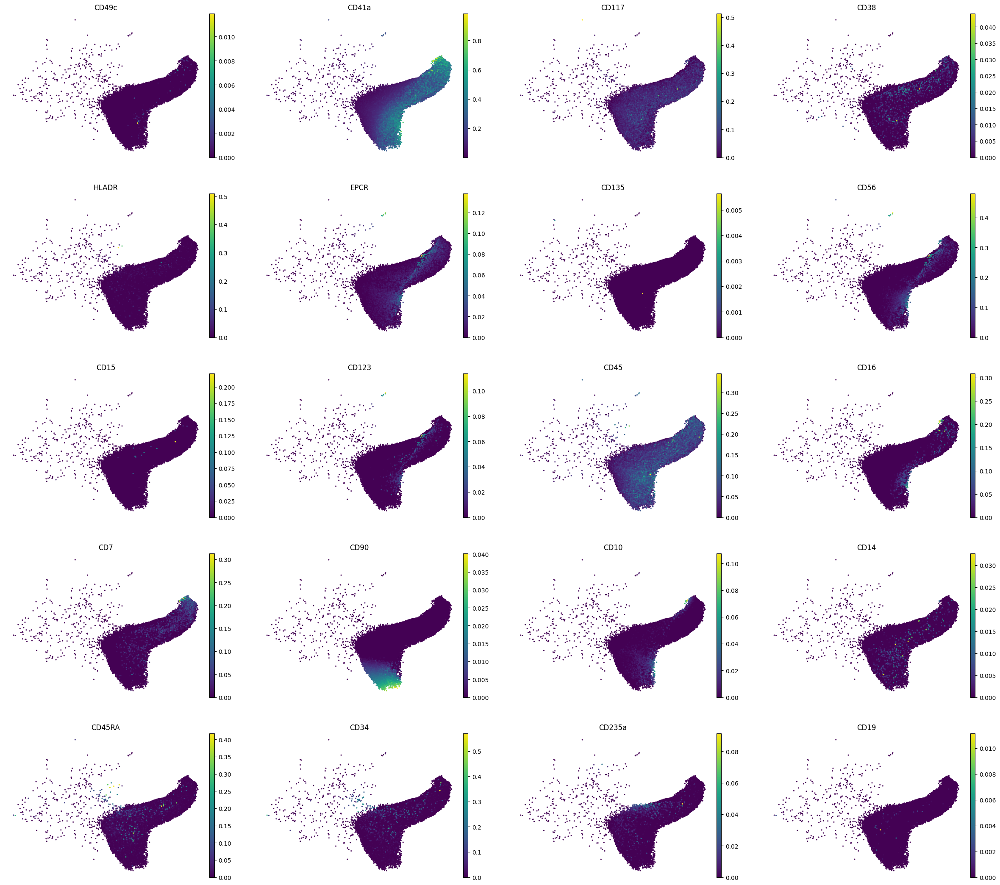

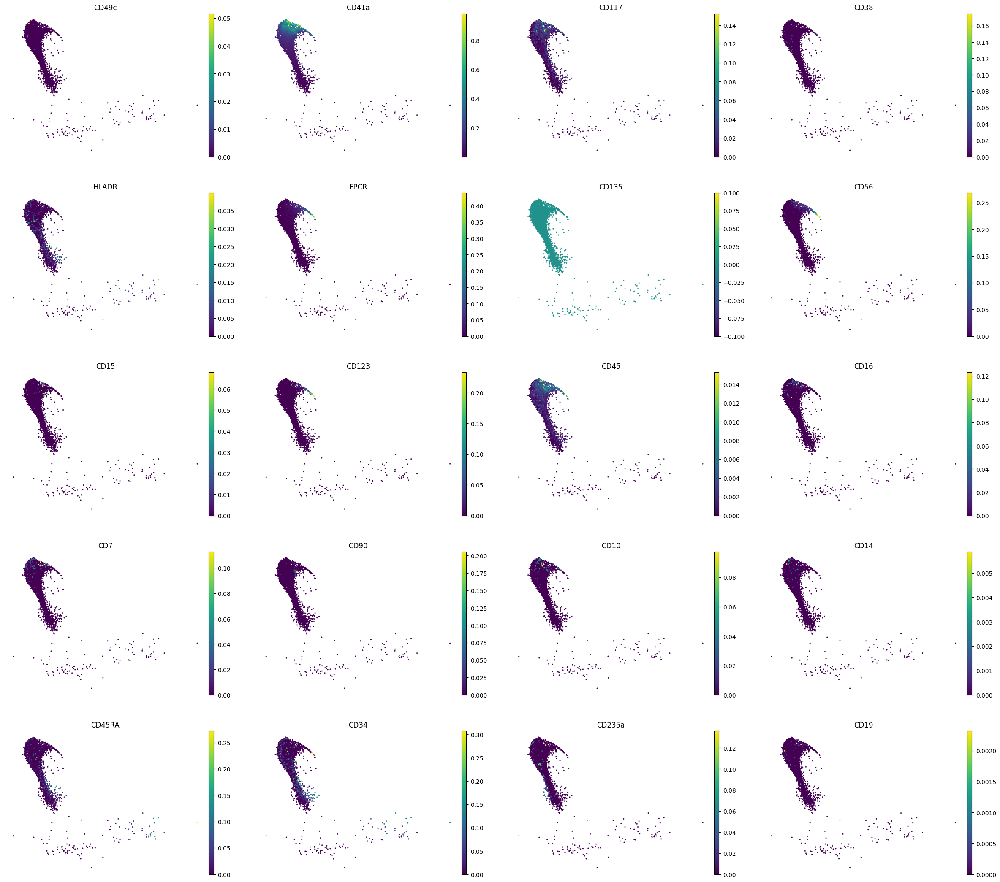

In [31]:
sc.pl.embedding(adata_new_MgkPro, "umap", color=adata_new_MgkPro.var_names, frameon=frameon, legend_loc=legend_loc, s=s)
sc.pl.embedding(adata_old_MgkPro, "umap", color=adata_old_MgkPro.var_names, frameon=frameon, legend_loc=legend_loc, s=s)


### Plot new adata by these genes.

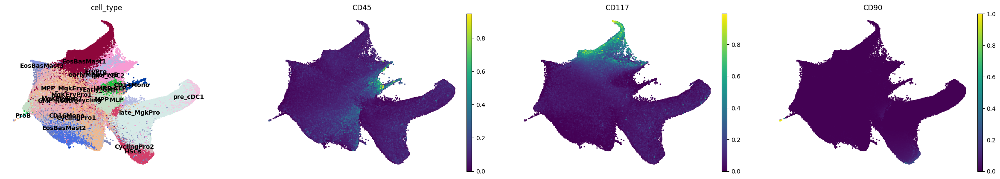

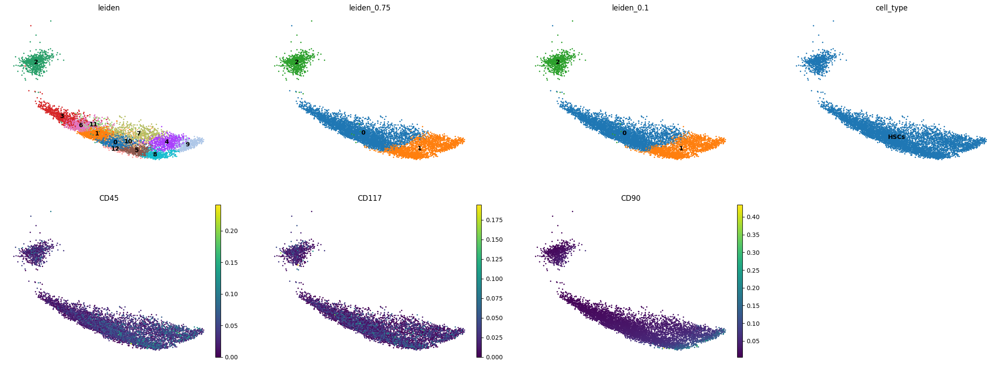

In [58]:
sc.pl.embedding(adata_new, "umap", color=["cell_type", "CD45", "CD117", "CD90"], frameon=frameon, legend_loc=legend_loc, s=s)
sc.pl.embedding(adata_new_HSCs, "umap", color=["leiden", "leiden_0.75", "leiden_0.1", "cell_type", "CD45", "CD117", "CD90"], frameon=frameon, legend_loc=legend_loc, s=s)

These genes seem to be expressed by EosBasoMastPre1 (CD117) and CD14Mono (CD45).

### Dotplot by leiden cluster.

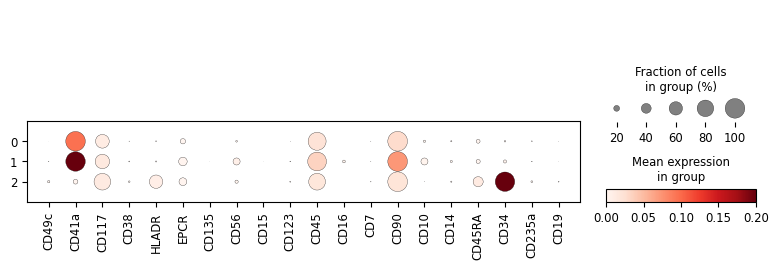

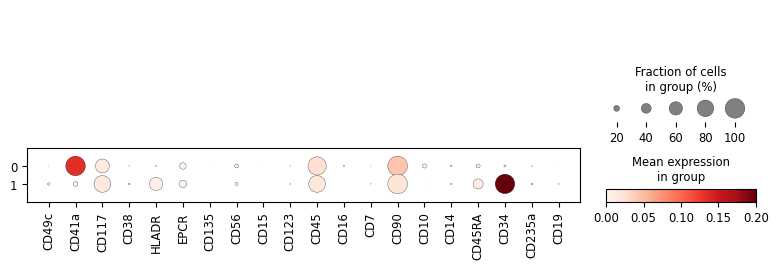

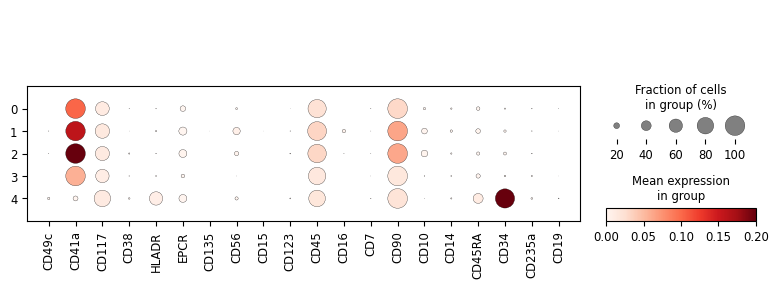

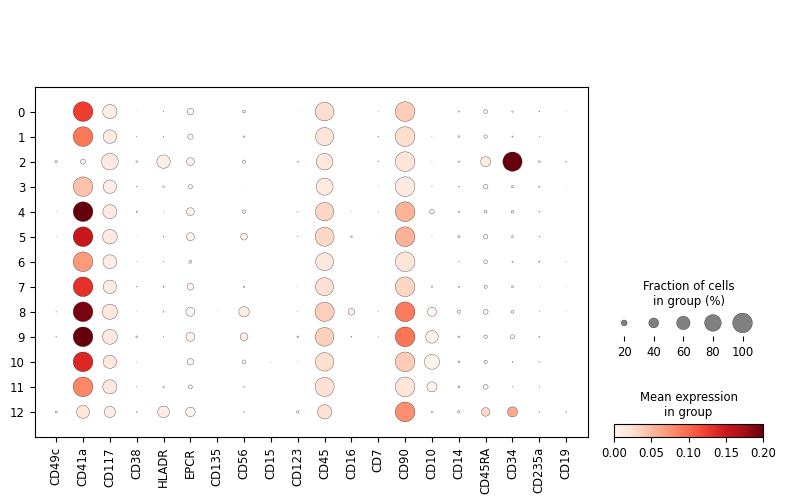

In [57]:
sc.pl.dotplot(
    adata_new_HSCs,
    var_names,
    "leiden_0.1",
    vmin=0.0,
    vmax=0.2
)
sc.pl.dotplot(
    adata_new_HSCs,
    var_names,
    "leiden_n100_0.75",
    vmin=0.0,
    vmax=0.2
)
sc.pl.dotplot(
    adata_new_HSCs,
    var_names,
    "leiden_0.5",
    vmin=0.0,
    vmax=0.2
)

sc.pl.dotplot(
    adata_new_HSCs,
    var_names,
    "leiden",
    vmin=0.0,
    vmax=0.2
)

**MgkPro and Leiden Cluster 0**

Compared to cells that were originally annotated as MgkPro, the ones coming from the leiden cluster 0 when using 100 neighbors and 0.75 resolution for leiden differ by the over-expression of CD90.

**HSCs and Leiden Cluster 1**

Compared to cells that were originally annotated as HSCs, the ones coming from the leiden cluster 1 when using 100 neighbors and 0.75 resolution for leiden differ by the over-expression of CD117 and CD45, their HLADR and CD90 expression seems reduced.

### Project Leiden Clustering to New Anndata.

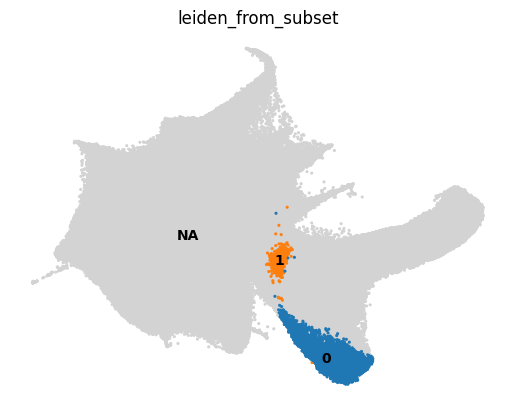

In [19]:
leiden_new = np.full(adata_new.shape[0], None, dtype=object)
leiden_new[HSCs_mask_new] = adata_new_HSCs.obs["leiden_n100_0.75"]
adata_new.obs["leiden_from_subset"] = leiden_new
sc.pl.embedding(adata_new, "umap", color=["leiden_from_subset"], frameon=frameon, legend_loc=legend_loc, s=s)

### Annotate cell type based on leiden cluster.

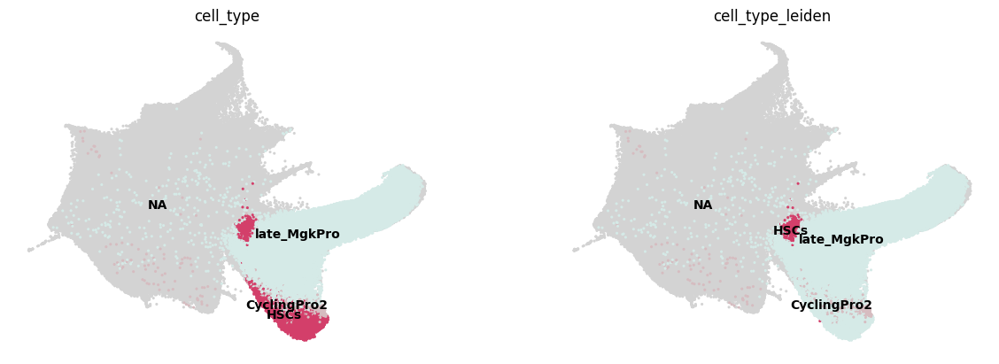

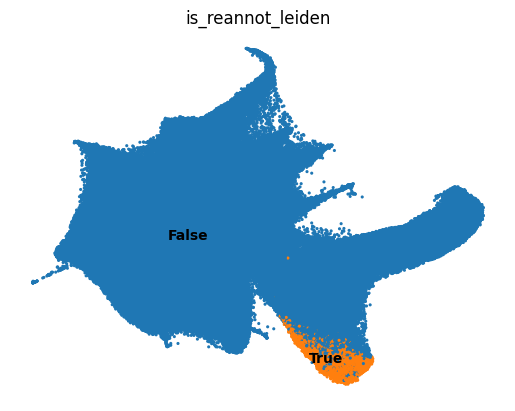

In [41]:
cell_type_leiden = adata_new.obs["cell_type"].copy()
leiden_0_mask = adata_new.obs["leiden_from_subset"] == "0"
cell_type_leiden[leiden_0_mask] = "late_MgkPro"
adata_new.obs["cell_type_leiden"] = cell_type_leiden
adata_new.obs["is_reannot_leiden"] = leiden_0_mask
sc.pl.embedding(adata_new, "umap", color=["cell_type", "cell_type_leiden"], groups=groups, frameon=frameon, legend_loc=legend_loc, s=s)
sc.pl.embedding(adata_new, "umap", color=["is_reannot_leiden"], frameon=frameon, legend_loc=legend_loc, s=s)

### Same but add new cell type.

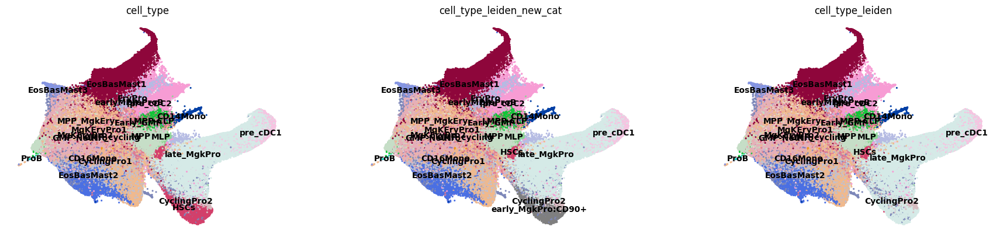

In [44]:
cell_type_leiden = adata_new.obs["cell_type"].copy()
leiden_0_mask = adata_new.obs["leiden_from_subset"] == "0"

# Ensure target category exists
target_ct = "early_MgkPro:CD90+"
if target_ct not in cell_type_leiden.cat.categories:
    cell_type_leiden = cell_type_leiden.cat.add_categories([target_ct])
cell_type_leiden[leiden_0_mask] = target_ct
adata_new.obs["cell_type_leiden_new_cat"] = cell_type_leiden
adata_new.obs["is_reannot_leiden"] = leiden_0_mask
sc.pl.embedding(adata_new, "umap", color=["cell_type", "cell_type_leiden_new_cat", "cell_type_leiden"], frameon=frameon, legend_loc=legend_loc, s=s)


## Concatenate and write.

### Prepare columns in old data.

In [50]:
for c in adata_new.obs.columns:
    if c.startswith("cell_type"):
        adata_old.obs[c] = adata_old.obs["cell_type"]

for c in adata_new.obs.columns:
    if c.startswith("is_reannot"):
        adata_old.obs[c] = False


### Concatenate.

In [53]:
adata_full_reannot = sc.concat((adata_old, adata_new), merge="same", uns_merge="same")
adata_full_reannot.obs_names_make_unique()
adata_full_reannot


/lustre/groups/ml01/workspace/lorenzo.consoli/micromamba/envs/sc_exp_design/lib/python3.12/site-packages/anndata/_core/anndata.py:1878: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/lustre/groups/ml01/workspace/lorenzo.consoli/micromamba/envs/sc_exp_design/lib/python3.12/site-packages/anndata/_core/anndata.py:1878: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 971828 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type', 'cell_type_max_threshold', 'cell_type_third_quartile_threshold', 'cell_type_leiden', 'cell_type_leiden_new_cat', 'is_reannot_max_threshold', 'is_reannot_third_quartile_threshold', 'is_reannot_leiden'
  

### Write to disk.

In [59]:
output_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/miscellaneous_new/BloodPlus_Loop2_logicle_reannot.h5ad"
adata_full_reannot.write_h5ad(output_path)
adata_full_reannot


AnnData object with n_obs × n_vars = 971828 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type', 'cell_type_max_threshold', 'cell_type_third_quartile_threshold', 'cell_type_leiden', 'cell_type_leiden_new_cat', 'is_reannot_max_threshold', 'is_reannot_third_quartile_threshold', 'is_reannot_leiden'
  

## Check proportions with reannotated data.


### Map experiment number to enrichment type.

In [ ]:
settings_experiments_map = {
    216:"late_mgkPro_low_u",
    217:"late_mgkPro_high_u",
    218:"late_mgkPro_high_u",
    219: "EryPro_low_u",
    220: "EryPro_high_u",
    221: "EryPro_high_u",
    222: "HSC_low_u",
    223: "HSC_high_u",
    224: "HSC_high_u",
    225: "preProB_low_u",
    226: "preProB_high_u",
    225: "preProB_low_u",
    226: "preProB_high_u",
    227: "preProB_high_u",
}

adata_new.obs["enrichment_type"] = adata_new.obs.experiment_number.map(lambda e: settings_experiments_map[int(e)])


### Plot proportions.

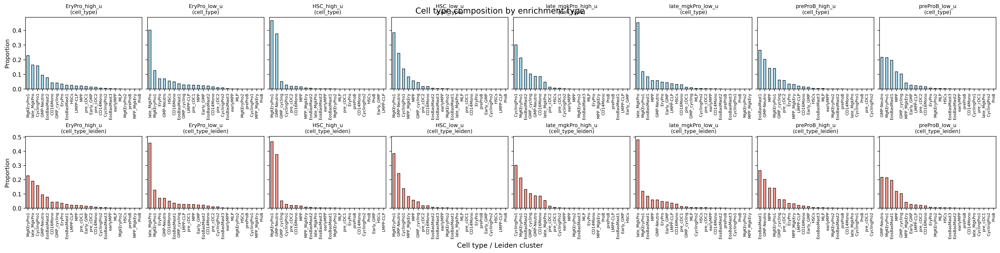

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Prepare data
# ------------------------------------------------------------
# Get unique enrichment types (sorted)
enrichment_types = sorted(adata_new.obs["enrichment_type"].unique())
n_cols = len(enrichment_types)

# Create a figure with 2 rows and as many columns
fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 3, 6), dpi=300,
                         sharey='row', constrained_layout=True)

# Handle case when only one enrichment type
if n_cols == 1:
    axes = axes.reshape(2, 1)

# ------------------------------------------------------------
# 2. Plot for each enrichment type
# ------------------------------------------------------------
for i, et in enumerate(enrichment_types):
    # Subset to current enrichment type
    mask = adata_new.obs["enrichment_type"] == et
    subset = adata_new.obs[mask]
    
    # ---- Top row: cell_type proportions ----
    ax_top = axes[0, i]
    # Compute proportions for cell_type
    ct_counts = subset["cell_type"].value_counts()
    ct_props = ct_counts / ct_counts.sum()
    # Plot bar chart
    ct_props.plot(kind='bar', ax=ax_top, color='skyblue', edgecolor='black', alpha=0.8)
    ax_top.set_title(f"{et}\n(cell_type)", fontsize=9)
    ax_top.set_ylabel("Proportion")
    ax_top.set_xlabel("")
    ax_top.tick_params(axis='x', rotation=90, labelsize=7)
    
    # ---- Bottom row: cell_type_leiden proportions ----
    ax_bottom = axes[1, i]
    leiden_counts = subset["cell_type_leiden"].value_counts()
    leiden_props = leiden_counts / leiden_counts.sum()
    leiden_props.plot(kind='bar', ax=ax_bottom, color='salmon', edgecolor='black', alpha=0.8)
    ax_bottom.set_title(f"{et}\n(cell_type_leiden)", fontsize=9)
    ax_bottom.set_ylabel("Proportion")
    ax_bottom.set_xlabel("")
    ax_bottom.tick_params(axis='x', rotation=90, labelsize=7)

# Add common x‑label (centred)
fig.supxlabel("Cell type / Leiden cluster", fontsize=12)

# Optional: add a global title
fig.suptitle("Cell type composition by enrichment type", fontsize=14, y=0.98)

# Save figure
plt.show()
